# Comparing the two approximate indexes : `SimHashIndexANN` and `SSHIndexANN`

In this notebook, we will compare the two approximate nearest neighbour (ANN) indexes of the whole-series similarity search module, `SimHashIndexANN` and `SSHIndexANN`. They do not hash the same thing, so the one to use depends on a property of your data that we can check.

For an introduction to the module see [Time Series Similarity Search with aeon](similarity_search.ipynb), for the mechanics of the random projections the [SimHash deep dive](simhash_index.ipynb), and for the tuning of each index the [performance notebook](code_speed.ipynb).

## What the two indexes hash

`SimHashIndexANN` projects the whole series on random Gaussian vectors and keeps the sign of each projection. Two series collide on a given bit with probability $1 - \theta/\pi$, where $\theta$ is the angle between them, so the index is a locality-sensitive hash for cosine similarity. As the projection treats the series as one vector, moving a pattern in time moves that vector with it.

`SSHIndexANN` slides a short filter over the series and keeps one bit per position, then counts the $n$-grams of that bit string and hashes the resulting multiset. Such a multiset records which local patterns occurred and how often, but not where. What it hashes is the weighted Jaccard similarity of these multisets, which correlates empirically with DTW.

We can compute both representations with a few lines of numpy, to see what a shift does to them.

In [1]:
import warnings
from collections import Counter

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from aeon.datasets import load_classification
from aeon.similarity_search.whole_series import (
    NaiveSeriesSearch,
    SimHashIndexANN,
    SSHIndexANN,
)
from aeon.utils.numba.general import z_normalise_series_2d

K = 5
X, _ = load_classification("ECG5000")
X = X[np.random.default_rng(0).permutation(len(X))]
queries, db = X[:20], X[20:2020]
print("collection shape :", db.shape)
print("queries shape    :", queries.shape)

collection shape : (2000, 1, 140)
queries shape    : (20, 1, 140)


In [2]:
rng = np.random.default_rng(0)
projections = rng.normal(size=(64, db.shape[2]))
filter_, shingle_size = rng.normal(size=30), 15


def simhash_bits(x):
    """Sign of the projection of the whole series on each random vector."""
    return (projections @ x > 0).astype(np.uint8)


def ssh_sketch(x):
    """Sign of the random filter at every position of the series."""
    windows = np.lib.stride_tricks.sliding_window_view(x, filter_.shape[0])
    return (windows @ filter_ > 0).astype(np.uint8)


def ssh_shingles(bits):
    """Count the n-grams of a bit string into a multiset."""
    positions = range(bits.shape[0] - shingle_size + 1)
    return Counter(bits[j : j + shingle_size].tobytes() for j in positions)


def cosine(x, y):
    """Similarity hashed by SimHash."""
    return x @ y / (np.linalg.norm(x) * np.linalg.norm(y))


def weighted_jaccard(x, y):
    """Similarity hashed by SSH."""
    a, b = ssh_shingles(ssh_sketch(x)), ssh_shingles(ssh_sketch(y))
    return sum((a & b).values()) / sum((a | b).values())


shifts = np.arange(21)
sample = z_normalise_series_2d(db[rng.choice(len(db), 30, replace=False)][:, 0])
cosines = [np.mean([cosine(x, np.roll(x, s)) for x in sample]) for s in shifts]
jaccards = [
    np.mean([weighted_jaccard(x, np.roll(x, s)) for x in sample]) for s in shifts
]
print("cosine          ", np.round(cosines, 2))
print("weighted jaccard", np.round(jaccards, 2))

cosine           [1.   0.94 0.84 0.72 0.6  0.49 0.4  0.32 0.26 0.22 0.18 0.16 0.14 0.13
 0.12 0.12 0.11 0.1  0.08 0.07 0.06]
weighted jaccard [1.   0.98 0.96 0.94 0.92 0.9  0.88 0.87 0.85 0.83 0.81 0.8  0.78 0.76
 0.75 0.73 0.72 0.7  0.69 0.68 0.66]


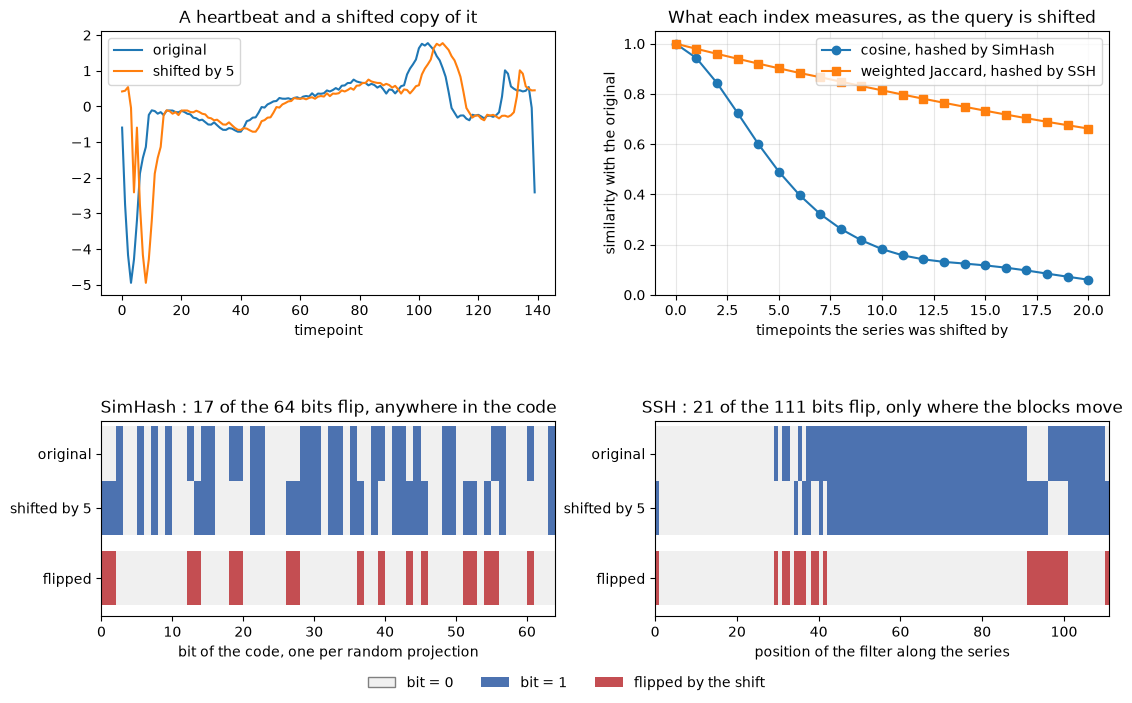

In [3]:
SHIFT = 5
beat = sample[0]
rolled = np.roll(beat, SHIFT)
bitmap, diff = ListedColormap(["#f0f0f0", "#4c72b0"]), ListedColormap(
    ["#f0f0f0", "#c44e52"]
)

fig = plt.figure(figsize=(13, 7.6))
grid = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.55, wspace=0.22)

ax = fig.add_subplot(grid[0, 0])
ax.plot(beat, label="original")
ax.plot(rolled, label=f"shifted by {SHIFT}")
ax.set_title("A heartbeat and a shifted copy of it")
ax.set_xlabel("timepoint")
ax.legend()

ax = fig.add_subplot(grid[0, 1])
ax.plot(shifts, cosines, "o-", color="tab:blue", label="cosine, hashed by SimHash")
ax.plot(
    shifts, jaccards, "s-", color="tab:orange", label="weighted Jaccard, hashed by SSH"
)
ax.set_title("What each index measures, as the query is shifted")
ax.set_xlabel("timepoints the series was shifted by")
ax.set_ylabel("similarity with the original")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

panels = (
    (
        "SimHash",
        "bit of the code, one per random projection",
        simhash_bits(beat),
        simhash_bits(rolled),
        "anywhere in the code",
    ),
    (
        "SSH",
        "position of the filter along the series",
        ssh_sketch(beat),
        ssh_sketch(rolled),
        "only where the blocks move",
    ),
)
for column, (name, xlabel, bits_a, bits_b, where) in enumerate(panels):
    ax = fig.add_subplot(grid[1, column])
    flipped = (bits_a != bits_b).astype(np.uint8)
    ax.imshow(
        np.stack([bits_a, bits_b]),
        aspect="auto",
        cmap=bitmap,
        interpolation="nearest",
        extent=(0, len(bits_a), 1.5, 3.5),
        vmin=0,
        vmax=1,
    )
    ax.imshow(
        flipped[None],
        aspect="auto",
        cmap=diff,
        interpolation="nearest",
        extent=(0, len(bits_a), 0.2, 1.2),
        vmin=0,
        vmax=1,
    )
    ax.set_ylim(0, 3.6)
    ax.set_yticks([3.0, 2.0, 0.7], ["original", f"shifted by {SHIFT}", "flipped"])
    ax.set_xlabel(xlabel)
    ax.set_title(f"{name} : {flipped.sum()} of the {len(bits_a)} bits flip, {where}")

fig.legend(
    handles=[
        Patch(facecolor="#f0f0f0", edgecolor="grey", label="bit = 0"),
        Patch(facecolor="#4c72b0", label="bit = 1"),
        Patch(facecolor="#c44e52", label="flipped by the shift"),
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
)
plt.show()

As you can see, the two similarities do not react in the same way to a shift. The cosine of a beat with its own shifted copy is down to 0.5 after five timepoints out of 140, and to 0.06 after twenty, while the weighted Jaccard is still at 0.66. The bottom row shows why : the bits of the SimHash code flip all over the code, as each of them looks at the whole series, while the sketch of SSH only changes where the blocks move, and the $n$-grams away from these edges are left untouched.

## Both indexes re-rank, so the hash only chooses the candidates

A query probes one bucket per table and collects the union of what it finds, the candidate set. `SSHIndexANN` scores these candidates with a real distance, DTW by default, and `SimHashIndexANN` ranks them by collision count unless we set `rerank_distance`. We give both the same re-ranking distance below, so that the only thing left to compare is which series get scored at all.

Both indexes trade the size of the candidate set against recall, so we report recall against the fraction of the collection that had to be scored. A random candidate set of fraction $p$ contains a given neighbour with probability $p$, so the line recall $= p$ is what doing nothing achieves.

The gold standard is an exhaustive DTW search over the same collection, so recall always means recall of the true DTW nearest neighbours. We read the size of the candidate set from `_gather_candidates`, a private method we use here only to instrument the index, as `predict` does not tell us how many series it scored.

In [4]:
exact = NaiveSeriesSearch(normalize=True, distance="dtw", n_jobs=-1).fit(db)
gold = [set(exact.predict(q, k=K)[0]) for q in queries]


def recall_and_probe(index):
    """Return mean recall@K against exact DTW, and mean fraction of the db probed."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        index.fit(db)
        recalls, probed = [], []
        for query, truth in zip(queries, gold):
            neighbours, _ = index.predict(query, k=K)
            recalls.append(len(set(neighbours) & truth) / K)
            candidates, _ = index._gather_candidates(z_normalise_series_2d(query))
            probed.append(len(candidates) / len(db))
    return np.mean(recalls), np.mean(probed)

### Aligned queries : SimHash finds the better candidates

ECG5000 heartbeats are aligned with one another, which is the usual situation for a collection of curated series. We sweep the selectivity of each index, `n_bits_per_table` for SimHash and `n_hashes_per_table` for SSH, so that each one traces its own recall against probe curve. Both are re-ranked with DTW.

In [5]:
bits_values, hashes_values = (8, 12, 16, 20, 24), (2, 3, 4, 6, 8)
sweep = {
    "SimHashIndexANN": (
        "n_bits_per_table",
        bits_values,
        [
            SimHashIndexANN(
                n_tables=40, n_bits_per_table=b, rerank_distance="dtw", random_state=0
            )
            for b in bits_values
        ],
    ),
    "SSHIndexANN": (
        "n_hashes_per_table",
        hashes_values,
        [
            SSHIndexANN(
                window_length=30,
                shift=2,
                shingle_size=15,
                n_tables=40,
                n_hashes_per_table=k,
                random_state=0,
            )
            for k in hashes_values
        ],
    ),
}
curves = {
    name: np.array([recall_and_probe(index) for index in indexes])
    for name, (_, _, indexes) in sweep.items()
}

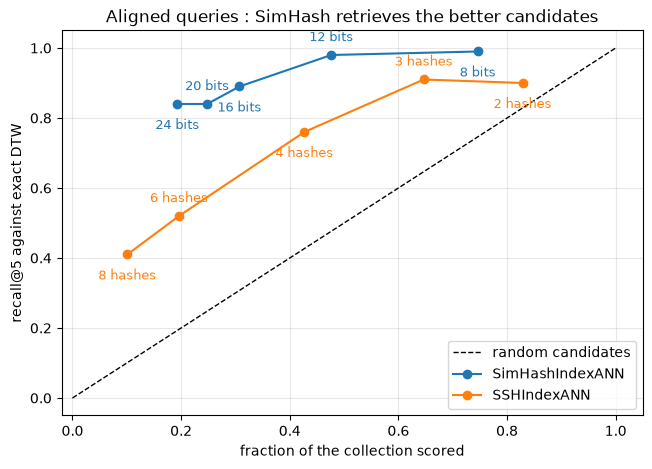

In [6]:
plt.figure(figsize=(7.5, 5))
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="random candidates")
units = {"SimHashIndexANN": "bits", "SSHIndexANN": "hashes"}
for name, colour in (("SimHashIndexANN", "tab:blue"), ("SSHIndexANN", "tab:orange")):
    _, values, _ = sweep[name]
    curve = curves[name]
    plt.plot(curve[:, 1], curve[:, 0], "o-", color=colour, label=name)
    for rank, ((recall, probed), value) in enumerate(zip(curve, values)):
        plt.annotate(
            f"{value} {units[name]}",
            (probed, recall),
            textcoords="offset points",
            xytext=(0, 10) if rank % 2 else (0, -18),
            ha="center",
            color=colour,
            fontsize=9,
        )
plt.xlabel("fraction of the collection scored")
plt.ylabel(f"recall@{K} against exact DTW")
plt.title("Aligned queries : SimHash retrieves the better candidates")
plt.xlim(-0.02, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Both curves are above the diagonal, so both hashes do something, but SimHash is above SSH everywhere. Scoring around a fifth of the collection, it recovers most of the true DTW neighbours, where SSH recovers about half of them.

The SSH representation is the one built to correlate with DTW, so this deserves an explanation. SSH obtains its shift invariance by discarding where a pattern occurs, and on an aligned collection that information was signal, not noise.

### Misaligned queries : only the shingled index survives

We now break the alignment. Each query is a circularly shifted copy of a series of the index, so the right answer is known without a gold standard, and rolling a series only changes the position of its values.

We measure the hash itself, as the fraction of the 40 tables in which the shifted query still lands in the bucket of its source. Both indexes keep 40 tables, so the two are comparable. We report the probe fraction next to it, as a high collision rate obtained by gathering more candidates would not mean much.

In [7]:
sources = np.random.default_rng(1).choice(len(db), 60, replace=False)
shift_configs = {
    "SimHash 8 bits": SimHashIndexANN(n_tables=40, n_bits_per_table=8, random_state=0),
    "SimHash 16 bits": SimHashIndexANN(
        n_tables=40, n_bits_per_table=16, random_state=0
    ),
    "SSH shift=2": SSHIndexANN(
        window_length=30,
        shift=2,
        shingle_size=15,
        n_tables=40,
        n_hashes_per_table=4,
        random_state=0,
    ),
    "SSH shift=1": SSHIndexANN(
        window_length=30,
        shift=1,
        shingle_size=15,
        n_tables=40,
        n_hashes_per_table=4,
        random_state=0,
    ),
}

collided, probed = {}, {}
for name, index in shift_configs.items():
    index.fit(db)
    collided[name], probed[name] = [], []
    for shift in shifts:
        rolled = np.roll(db[sources], shift, axis=2)
        tables, sizes = [], []
        for query, source in zip(rolled, sources):
            candidates, counts = index._gather_candidates(z_normalise_series_2d(query))
            hit = counts[candidates == source]
            tables.append(hit[0] / index.n_tables if len(hit) else 0.0)
            sizes.append(len(candidates) / len(db))
        collided[name].append(np.mean(tables))
        probed[name].append(np.mean(sizes))

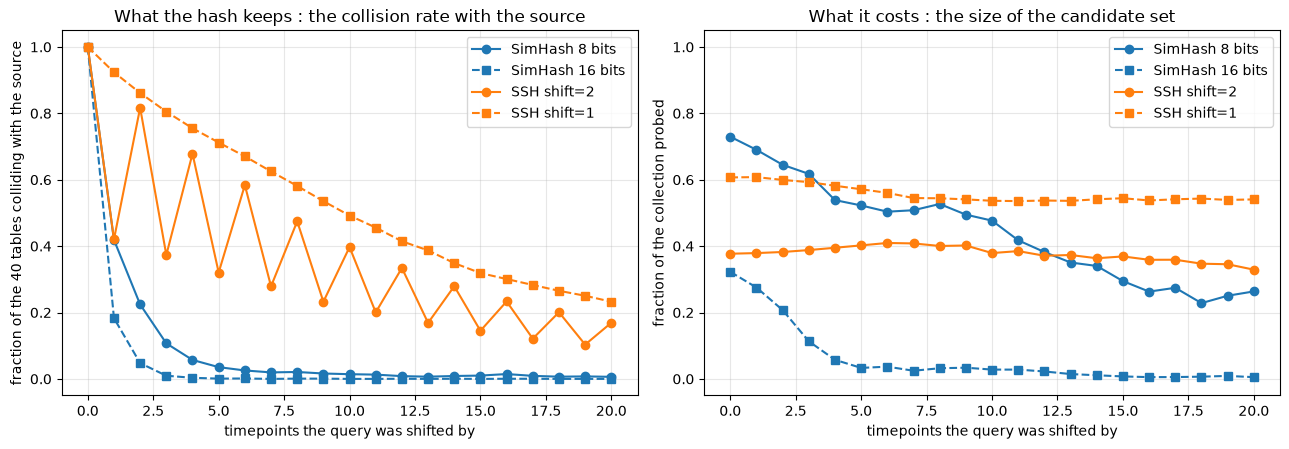

In [8]:
fig, (ax_hash, ax_cost) = plt.subplots(1, 2, figsize=(13, 4.6))
styles = {
    "SimHash 8 bits": ("tab:blue", "o-"),
    "SimHash 16 bits": ("tab:blue", "s--"),
    "SSH shift=2": ("tab:orange", "o-"),
    "SSH shift=1": ("tab:orange", "s--"),
}
for name, (colour, style) in styles.items():
    ax_hash.plot(shifts, collided[name], style, color=colour, label=name)
    ax_cost.plot(shifts, probed[name], style, color=colour, label=name)

ax_hash.set_ylabel("fraction of the 40 tables colliding with the source")
ax_hash.set_title("What the hash keeps : the collision rate with the source")
ax_cost.set_ylabel("fraction of the collection probed")
ax_cost.set_title("What it costs : the size of the candidate set")
for ax in (ax_hash, ax_cost):
    ax.set_xlabel("timepoints the query was shifted by")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As you can see, the SimHash collision rate falls very fast. A shift of two timepoints out of 140 already costs most of it, and nothing is left after ten. SSH still collides with its source at every shift we tested, and with $L = 40$ tables, a fifth of the tables colliding is enough for the source to reach the candidate set almost surely. The right panel shows what this costs, `SSH shift=2` stays near 0.4 at every shift while SimHash with 8 bits starts above 0.7. The candidate set of SimHash even shrinks as the query is displaced, the query simply moves to a region of the hash space where it collides with fewer series, the right ones included.

The oscillation of `SSH shift=2` comes from the step $\delta$ between two filter positions. A displacement that is a multiple of $\delta$ puts the filter back on the same offsets, while other displacements fall between two positions. If we do not know the displacements in advance, `shift=1` is the safer choice, at the cost of a longer sketch.

The collision rate tells us what the index offers, not what the query returns. We now run the same shifted queries through `predict`, with DTW re-ranking on both indexes, and compare the rate at which the source reaches the candidate set with the rate at which it comes out in the top $k$.

In [9]:
rerank_shifts = [0, 2, 5, 10, 20]
rerank_sources = sources[:30]
rerank_configs = {
    "SimHash 8 bits": SimHashIndexANN(
        n_tables=40, n_bits_per_table=8, rerank_distance="dtw", random_state=0
    ),
    "SSH shift=1": SSHIndexANN(
        window_length=30,
        shift=1,
        shingle_size=15,
        n_tables=40,
        n_hashes_per_table=4,
        random_state=0,
    ),
}

offered, returned = {}, {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, index in rerank_configs.items():
        index.fit(db)
        offered[name], returned[name] = [], []
        for shift in rerank_shifts:
            rolled = np.roll(db[rerank_sources], shift, axis=2)
            in_candidates, in_topk = [], []
            for query, source in zip(rolled, rerank_sources):
                candidates, _ = index._gather_candidates(z_normalise_series_2d(query))
                in_candidates.append(source in candidates)
                in_topk.append(source in index.predict(query, k=K)[0])
            offered[name].append(np.mean(in_candidates))
            returned[name].append(np.mean(in_topk))

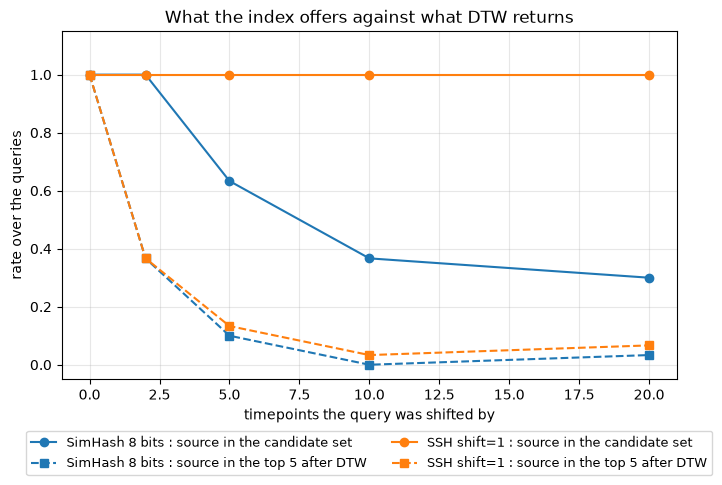

In [10]:
plt.figure(figsize=(7.5, 5))
for name, colour in (("SimHash 8 bits", "tab:blue"), ("SSH shift=1", "tab:orange")):
    plt.plot(
        rerank_shifts,
        offered[name],
        "o-",
        color=colour,
        label=f"{name} : source in the candidate set",
    )
    plt.plot(
        rerank_shifts,
        returned[name],
        "s--",
        color=colour,
        label=f"{name} : source in the top {K} after DTW",
    )
plt.xlabel("timepoints the query was shifted by")
plt.ylabel("rate over the queries")
plt.title("What the index offers against what DTW returns")
plt.ylim(-0.05, 1.15)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As you can see, the two rates do not agree for SSH. The index keeps offering the source, but DTW does not rank it in the top $k$. A DTW warping path is monotone, so it cannot bring the end of a query back to its start, and a rolled heartbeat is no longer its own DTW nearest neighbour. An invariance of the index only survives as far as the distance we re-rank with.

## Which index should you use ?

| | `SimHashIndexANN` | `SSHIndexANN` |
|---|---|---|
| hashes | sign of a projection of the whole series | multiset of $n$-grams of a sliding sign sketch |
| exact for | cosine similarity, $1 - \theta/\pi$ per bit | weighted Jaccard of the shingle multisets |
| aligned collections | recovers most DTW neighbours from a fifth of the collection | needs to score far more for the same recall |
| shifted queries | collision rate collapses at a 2-timepoint shift | holds at every shift tested |
| ranking | collision count, or `rerank_distance` | always a real distance |
| cheapest query | yes, with `rerank_distance=None`, no distance is computed | no, every candidate is scored |
| selectivity dial | `n_bits_per_table` | `n_hashes_per_table` |

The question to ask is whether the same pattern can appear at different offsets in your collection.

- If it cannot, as in curated and aligned series, use `SimHashIndexANN`. We can leave `rerank_distance=None` when a rough neighbourhood is enough, and set it to the distance we care about when the ordering has to be right.
- If it can, as in subsequences taken at arbitrary positions of a long series, use `SSHIndexANN` with `shift=1`.
- If you are not sure, run the shifted query experiment above on your own data, it needs no labels and no gold standard.

## Conclusion

We saw that the two indexes are not ordered by quality but by assumption. Once both re-rank with the same distance, `SimHashIndexANN` retrieves the better candidates on aligned collections, while `SSHIndexANN` is the only one that still retrieves anything once the queries are displaced in time.

### References

- M. S. Charikar, "Similarity estimation techniques from rounding algorithms", STOC 2002 (introduces SimHash as an LSH family for cosine similarity).
- P. Indyk and R. Motwani, "Approximate nearest neighbors : towards removing the curse of dimensionality", STOC 1998 (the multi-table $(k, L)$ scheme).
- C. Luo and A. Shrivastava, "SSH (Sketch, Shingle, & Hash) for Indexing Massive-Scale Time Series", arXiv:1610.07328, 2016 (the SSH index).
- A. Z. Broder, S. C. Glassman, M. S. Manasse and G. Zweig, "Syntactic clustering of the web", WWW 1997 (MinHash for set similarity).